In [37]:
# imprts
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from analysis_ad_ab import (
    load_adab_participant,
    summarize_participant_adab,
    collect_calibration_points,
    plot_adab_trial_grid,
    plot_combined_parasitic_relationship,
    add_calibration_variability,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [38]:
# participant movement windows
PARTICIPANTS = {
    "11_2_25": {
        "root_dir": "CSV Data/11_2_25",
        "windows_first": [
            (0.00, 3.44, 3.45, 9.84), # Note: video cuts out during movement 
            (0.00, 3.39, 3.40, 9.90),
            (0.00, 3.34, 3.35, 9.90),
        ],
        "windows_second": [
            (0.00, 3.39, 3.40, 9.84),
            (0.00, 3.49, 3.50, 9.90),
            (0.00, 3.34, 3.35, 9.84),
        ],
    },
    "11_4_25": {
        "root_dir": "CSV Data/11_4_25",
        "windows_first": [
            (0.00, 3.44, 3.45, 9.84),
            (0.00, 3.44, 3.45, 9.90),
            (0.00, 3.39, 3.40, 9.84),
        ],
        "windows_second": [
            (0.00, 3.39, 3.40, 9.84), # Note: finger goes past 20 degree mark and seems to be slightly lifting off the table
            (0.00, 3.39, 3.40, 9.90),
            (0.00, 3.39, 3.40, 9.90),
        ],
    },
    "11_7_25": {
        "root_dir": "CSV Data/11_7_25",
        "windows_first": [
            (0.00, 3.59, 3.60, 9.84),
            (0.00, 3.54, 3.55, 9.84),
            (0.00, 3.49, 3.50, 9.90),
        ],
        "windows_second": [
            (0.00, 3.42, 3.43, 9.90),
            (0.00, 3.39, 3.40, 9.90),
            (0.00, 3.59, 3.60, 9.84),
        ],
    },
}

results = {}
for participant, spec in PARTICIPANTS.items():
    results[participant] = load_adab_participant(
        participant=participant,
        root_dir=spec["root_dir"],
        clamp_theta=False,          # keep unclamped; clamping done later if needed
    )

In [39]:
"""
Verifies that each of the 6 participant x app combos got its OWN calibration curve.
If any entry is None the calibration failed for that combo.
"""

print("=" * 60)
print("CALIBRATION POLYNOMIAL COEFFICIENTS (highest→lowest degree)")
print("=" * 60)
for participant, res in results.items():
    for app_key in ("app1", "app2"):
        coeffs = res["coeffs_labeled"].get(app_key)
        tag = f"  {participant}  {app_key}"
        if coeffs is None:
            print(f"{tag}  →  *** NO CALIBRATION FOUND ***")
        else:
            coeff_str = np.array2string(np.array(coeffs), precision=6, suppress_small=True)
            print(f"{tag}  →  {coeff_str}")
print()

CALIBRATION POLYNOMIAL COEFFICIENTS (highest→lowest degree)
  11_2_25  app1  →  [    -0.            0.017318 -76557.211908]
  11_2_25  app2  →  [    -0.            0.007281 -31479.178958]
  11_4_25  app1  →  [    0.          -0.003648 18484.341807]
  11_4_25  app2  →  [   -0.           0.000559 -1049.816764]
  11_7_25  app1  →  [    0.          -0.002914 15094.574265]
  11_7_25  app2  →  [    -0.            0.012589 -55224.396582]



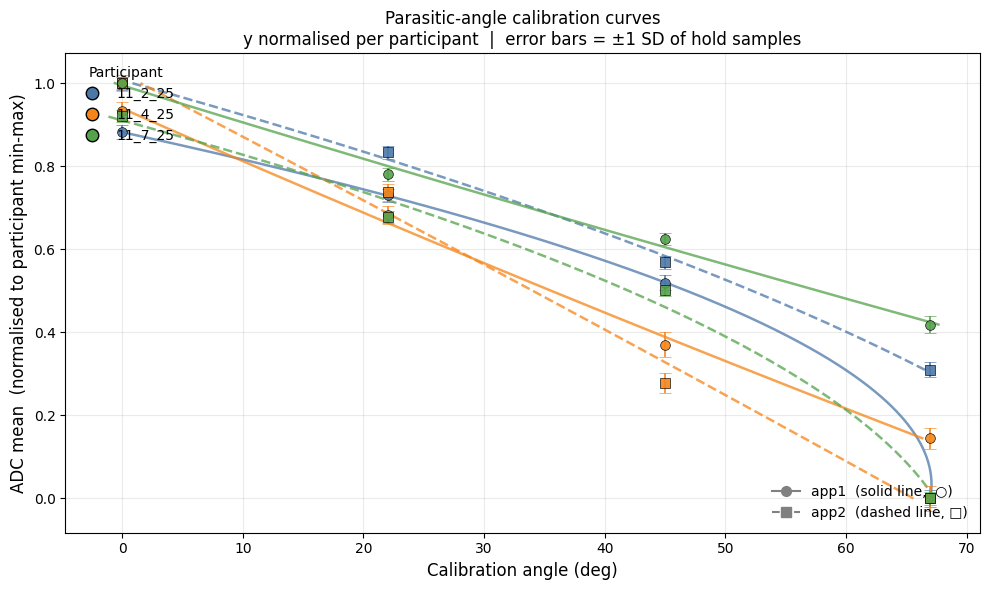

In [40]:
# ── 1. collect calibration points with variability ───────────────────────────
all_calib_dfs = []
for participant, res in results.items():
    calib_df = collect_calibration_points(res)
    if not calib_df.empty:
        calib_df = add_calibration_variability(calib_df)   # adds adc_std, adc_sem
        all_calib_dfs.append(calib_df)

all_calib = pd.concat(all_calib_dfs, ignore_index=True)

# ── 2. compute per-participant ADC min/max (across BOTH apps) ─────────────────
participant_adc_range = (
    all_calib
    .groupby("participant")["adc_mean"]
    .agg(adc_global_min="min", adc_global_max="max")
)

def norm_adc(adc_values, p_min, p_max):
    """Linear rescale to [0, 1] using participant-level min/max."""
    rng = p_max - p_min
    if rng == 0:
        return np.zeros_like(adc_values, dtype=float)
    return (np.asarray(adc_values, dtype=float) - p_min) / rng

# ── 3. plot ───────────────────────────────────────────────────────────────────
palette = {
    "11_2_25": "#4C78A8",
    "11_4_25": "#F58518",
    "11_7_25": "#54A24B",
}
linestyles = {"app1": "-", "app2": "--"}
markers    = {"app1": "o", "app2": "s"}

fig, ax = plt.subplots(figsize=(10, 6))

for participant in PARTICIPANTS:
    p_min = participant_adc_range.loc[participant, "adc_global_min"]
    p_max = participant_adc_range.loc[participant, "adc_global_max"]
    color = palette.get(participant, "#999999")

    for app_key in ["app1", "app2"]:
        sub = (
            all_calib[
                (all_calib["participant"] == participant) &
                (all_calib["application"] == app_key)
            ]
            .sort_values("angle_snap_deg")
            .copy()
        )
        if sub.empty:
            continue

        x_pts   = sub["angle_snap_deg"].to_numpy(dtype=float)
        adc_raw = pd.to_numeric(sub["adc_mean"], errors="coerce").to_numpy(dtype=float)
        adc_std = pd.to_numeric(sub["adc_std"],  errors="coerce").to_numpy(dtype=float)

        y_pts   = norm_adc(adc_raw, p_min, p_max)
        y_err   = adc_std / (p_max - p_min)          # same scale factor

        label = f"{participant}  {app_key}"
        ls    = linestyles[app_key]
        mk    = markers[app_key]
        alpha_fill = 0.18 if app_key == "app1" else 0.10

        # error bars + scatter
        ax.errorbar(
            x_pts, y_pts,
            yerr=y_err,
            fmt=mk,
            color=color,
            ecolor=color,
            elinewidth=1.3,
            capsize=4,
            markersize=7,
            markeredgecolor="black",
            markeredgewidth=0.5,
            alpha=0.9,
            label=label,
            zorder=4,
        )

        # polynomial overlay — evaluated on a fine ADC grid, then normalised
        coeffs = results[participant]["coeffs_labeled"].get(app_key)
        if coeffs is not None and adc_raw.size >= 2:
            adc_fit  = np.linspace(adc_raw.min(), adc_raw.max(), 400)
            angle_fit = np.polyval(coeffs, adc_fit)   # angle = poly(adc)
            y_fit    = norm_adc(adc_fit, p_min, p_max)

            ax.plot(
                angle_fit, y_fit,
                color=color,
                linestyle=ls,
                linewidth=1.8,
                alpha=0.75,
            )

# ── 4. legend: participants by colour, app by marker/linestyle ───────────────
from matplotlib.lines import Line2D

participant_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=c,
           markeredgecolor="black", markersize=9, label=p)
    for p, c in palette.items() if p in PARTICIPANTS
]
app_handles = [
    Line2D([0], [0], marker="o", linestyle="-",  color="gray",
           markersize=7, label="app1  (solid line,  ○)"),
    Line2D([0], [0], marker="s", linestyle="--", color="gray",
           markersize=7, label="app2  (dashed line, □)"),
]
leg1 = ax.legend(handles=participant_handles, title="Participant",
                 loc="upper left", frameon=False)
ax.add_artist(leg1)
ax.legend(handles=app_handles, loc="lower right", frameon=False)

ax.set_xlabel("Calibration angle (deg)", fontsize=12)
ax.set_ylabel("ADC mean  (normalised to participant min-max)", fontsize=12)
ax.set_title(
    "Parasitic-angle calibration curves\n"
    "y normalised per participant  |  error bars = ±1 SD of hold samples",
    fontsize=12,
)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [41]:
summary_tables = []
results_clamped = {}

for participant, spec in PARTICIPANTS.items():
    res = load_adab_participant(
        participant=participant,
        root_dir=spec["root_dir"],
        clamp_theta=True,
    )
    results_clamped[participant] = res

    summary_df = summarize_participant_adab(
        res,
        windows_first=spec["windows_first"],
        windows_second=spec["windows_second"],
    )
    summary_tables.append(summary_df)

all_summary = pd.concat(summary_tables, ignore_index=True)

In [42]:
"""
For each of the 6 combos prints:
  • Rest window:   mean, std, n
  • Move window:   mean, std, n, peak, ptp
  • Δ (move - rest): mean ± SD across trials
"""

SHOW_COLS_REST  = ["rest_angle_mean", "rest_angle_std", "rest_angle_n"]
SHOW_COLS_MOVE  = [
    "move_angle_mean", "move_angle_std", "move_angle_n",
    "movement_peak_angle_deg", "movement_ptp_angle_deg",
]
DELTA_COL       = "move_mean_minus_rest_mean_angle"

print("=" * 72)
print("REST vs MOVEMENT SUMMARY   (angle col = theta_cam_cal, deg)")
print("=" * 72)

for participant in PARTICIPANTS:
    for app in ["app1", "app2"]:
        sub = all_summary[
            (all_summary["participant"] == participant) &
            (all_summary["application"] == app)
        ].copy()

        if sub.empty:
            print(f"\n{participant}  {app}  — no data")
            continue

        print(f"\n── {participant}  |  {app}  ({len(sub)} trials) ──────────────")

        # per-trial table
        trial_disp = sub[[
            "trial",
            "rest_angle_mean", "rest_angle_std",
            "move_angle_mean", "move_angle_std",
            "movement_peak_angle_deg", "movement_ptp_angle_deg",
            DELTA_COL,
        ]].rename(columns={
            "rest_angle_mean": "rest_mean",
            "rest_angle_std":  "rest_sd",
            "move_angle_mean": "move_mean",
            "move_angle_std":  "move_sd",
            "movement_peak_angle_deg": "move_peak",
            "movement_ptp_angle_deg":  "move_ptp",
            DELTA_COL:                 "delta",
        }).set_index("trial")

        print(trial_disp.round(2).to_string())

        # aggregate across trials
        deltas = pd.to_numeric(sub[DELTA_COL], errors="coerce").dropna()
        print(
            f"\n  Δ (move-rest) across trials:  "
            f"mean = {deltas.mean():.2f}°,  "
            f"SD = {deltas.std(ddof=1):.2f}°,  "
            f"n = {len(deltas)}"
        )
print()

REST vs MOVEMENT SUMMARY   (angle col = theta_cam_cal, deg)

── 11_2_25  |  app1  (3 trials) ──────────────
       rest_mean  rest_sd  move_mean  move_sd  move_peak  move_ptp  delta
trial                                                                    
1            0.0      0.0        0.0      0.0        0.0       0.0    0.0
2            0.0      0.0        0.0      0.0        0.0       0.0    0.0
3            0.0      0.0        0.0      0.0        0.0       0.0    0.0

  Δ (move−rest) across trials:  mean = 0.00°,  SD = 0.00°,  n = 3

── 11_2_25  |  app2  (3 trials) ──────────────
       rest_mean  rest_sd  move_mean  move_sd  move_peak  move_ptp  delta
trial                                                                    
1           0.01     0.08       0.04     0.25       4.26      4.26   0.03
2           0.01     0.11       0.01     0.13       2.31      2.31   0.00
3           0.13     0.41       0.35     0.89       6.84      6.84   0.22

  Δ (move−rest) across trials:  mean

In [61]:
summary_tables_clamped = []

for participant, spec in PARTICIPANTS.items():
    summary_df = summarize_participant_adab(
        results_clamped[participant],          # <-- clamped
        windows_first=spec["windows_first"],
        windows_second=spec["windows_second"],
    )
    summary_tables_clamped.append(summary_df)

all_summary = pd.concat(summary_tables_clamped, ignore_index=True)

In [62]:
rows = []
for participant in PARTICIPANTS:
    row = {"Participant": participant}
    for app in ["app1", "app2"]:
        sub = all_summary[
            (all_summary["participant"] == participant) &
            (all_summary["application"] == app)
        ]

        # pool all trials for this participant × app
        rest_vals = pd.to_numeric(sub["rest_angle_mean"], errors="coerce").dropna()
        move_vals = pd.to_numeric(sub["move_angle_mean"], errors="coerce").dropna()

        app_label = app.replace("app", "APP ")

        row[f"{app_label} Resting Mean"]  = rest_vals.mean()
        row[f"{app_label} Resting Stdv"]  = rest_vals.std(ddof=1)
        row[f"{app_label} Movement Mean"] = move_vals.mean()
        row[f"{app_label} Movement Stdv"] = move_vals.std(ddof=1)

    rows.append(row)

table = pd.DataFrame(rows).set_index("Participant")

# reorder columns to match the requested layout
col_order = [
    "APP 1 Resting Mean",  "APP 1 Resting Stdv",
    "APP 2 Resting Mean",  "APP 2 Resting Stdv",
    "APP 1 Movement Mean", "APP 1 Movement Stdv",
    "APP 2 Movement Mean", "APP 2 Movement Stdv",
]
table = table[col_order].round(2)

print(table.to_string())
table   # renders as a styled DataFrame in Jupyter

             APP 1 Resting Mean  APP 1 Resting Stdv  APP 2 Resting Mean  APP 2 Resting Stdv  APP 1 Movement Mean  APP 1 Movement Stdv  APP 2 Movement Mean  APP 2 Movement Stdv
Participant                                                                                                                                                                    
11_2_25                    0.00                0.00                0.05                0.07                 0.00                 0.00                 0.13                 0.19
11_4_25                    1.14                0.22                5.34                0.23                 1.14                 0.28                 6.16                 0.15
11_7_25                    0.38                0.48               10.82                0.30                 0.71                 0.59                12.21                 0.30


,APP 1 Resting Mean,APP 1 Resting Stdv,APP 2 Resting Mean,APP 2 Resting Stdv,APP 1 Movement Mean,APP 1 Movement Stdv,APP 2 Movement Mean,APP 2 Movement Stdv
Participant,,,,,,,,
11_2_25,0.00,0.00,0.05,0.07,0.00,0.00,0.13,0.19
11_4_25,1.14,0.22,5.34,0.23,1.14,0.28,6.16,0.15
11_7_25,0.38,0.48,10.82,0.30,0.71,0.59,12.21,0.30


In [57]:
for participant, res in results.items():
    calib_df = collect_calibration_points(res)
    print(participant, calib_df[["application", "angle_snap_deg", "adc_mean"]].to_string())
    print("  coeffs app1:", res["coeffs_labeled"]["app1"])
    print("  coeffs app2:", res["coeffs_labeled"]["app2"])

11_2_25   application  angle_snap_deg      adc_mean
0        app1             0.0  9.110725e+06
1        app1            22.0  9.063745e+06
2        app1            45.0  8.999078e+06
3        app1            67.0  8.838729e+06
4        app2             0.0  9.147190e+06
5        app2            22.0  9.095699e+06
6        app2            45.0  9.014002e+06
7        app2            67.0  8.934240e+06
  coeffs app1: [-9.78555494e-10  1.73183301e-02 -7.65572119e+04]
  coeffs app2: [-4.19749432e-10  7.28102295e-03 -3.14791790e+04]
11_4_25   application  angle_snap_deg      adc_mean
0        app1             0.0  9.157667e+06
1        app1            22.0  9.107699e+06
2        app1            45.0  9.045078e+06
3        app1            67.0  9.000017e+06
4        app2             0.0  9.171346e+06
5        app2            22.0  9.118603e+06
6        app2            45.0  9.026803e+06
7        app2            67.0  8.970938e+06
  coeffs app1: [ 1.77933019e-10 -3.64784288e-03  1.84843418e+0

In [59]:
grouped = (
    all_summary
    .groupby(["participant", "application"], sort=False)
    .agg(
        n_trials                 = ("trial",                          "count"),
        rest_mean_deg            = ("rest_angle_mean",                "mean"),
        rest_sd_deg              = ("rest_angle_std",                 "mean"),   # avg within-trial SD
        move_mean_deg            = ("movement_mean_angle_deg",        "mean"),
        move_peak_deg            = ("movement_peak_angle_deg",        "mean"),
        move_ptp_deg             = ("movement_ptp_angle_deg",         "mean"),
        delta_mean_deg           = (DELTA_COL,                        "mean"),
        delta_sd_across_trials   = (DELTA_COL,                        "std"),
    )
    .round(2)
    .reset_index()
)

print("GROUPED SUMMARY  (mean across trials per participant x app)")
print(grouped.to_string(index=False))

GROUPED SUMMARY  (mean across trials per participant x app)
participant application  n_trials  rest_mean_deg  rest_sd_deg  move_mean_deg  move_peak_deg  move_ptp_deg  delta_mean_deg  delta_sd_across_trials
    11_2_25        app1         3         -19.73         4.73         -20.92          -7.01         29.74           -1.19                    0.17
    11_2_25        app2         3          -2.90         1.67          -2.91           4.47         14.59           -0.01                    0.68
    11_4_25        app1         3           0.87         1.50           0.86           6.80         11.67           -0.02                    0.28
    11_4_25        app2         3           5.34         1.34           6.16          12.14         11.44            0.82                    0.17
    11_7_25        app1         3          -0.88         1.46           0.04           5.26         10.16            0.91                    0.26
    11_7_25        app2         3          10.82         1.50   

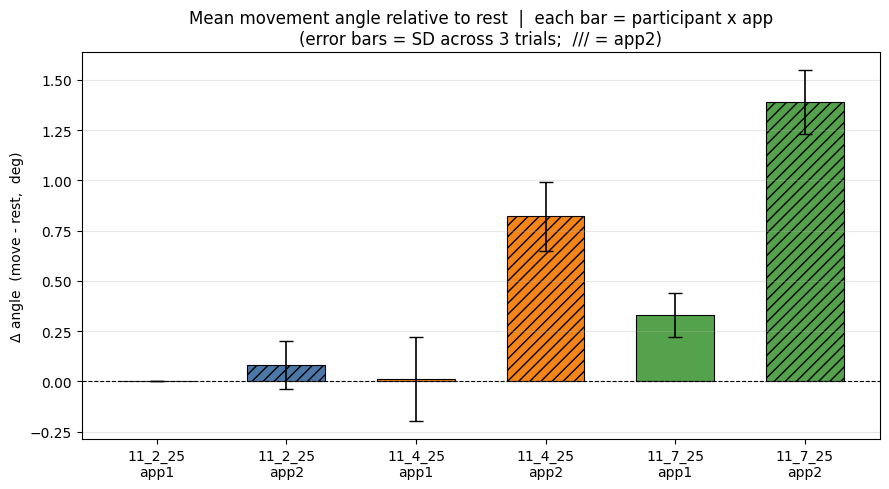

In [44]:
fig, ax = plt.subplots(figsize=(9, 5))

combo_labels = [
    f"{row.participant}\n{row.application}"
    for _, row in grouped.iterrows()
]
x = np.arange(len(grouped))
colors = [
    palette.get(row.participant, "#999999")
    for _, row in grouped.iterrows()
]
hatches = [
    "" if row.application == "app1" else "///"
    for _, row in grouped.iterrows()
]

bars = ax.bar(
    x,
    grouped["delta_mean_deg"],
    yerr=grouped["delta_sd_across_trials"],
    color=colors,
    hatch=hatches,
    edgecolor="black",
    linewidth=0.8,
    capsize=5,
    error_kw=dict(elinewidth=1.2),
    width=0.6,
)

ax.set_xticks(x)
ax.set_xticklabels(combo_labels, fontsize=10)
ax.set_ylabel("Δ angle  (move - rest,  deg)")
ax.set_title("Mean movement angle relative to rest  |  each bar = participant x app\n"
             "(error bars = SD across 3 trials;  /// = app2)")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


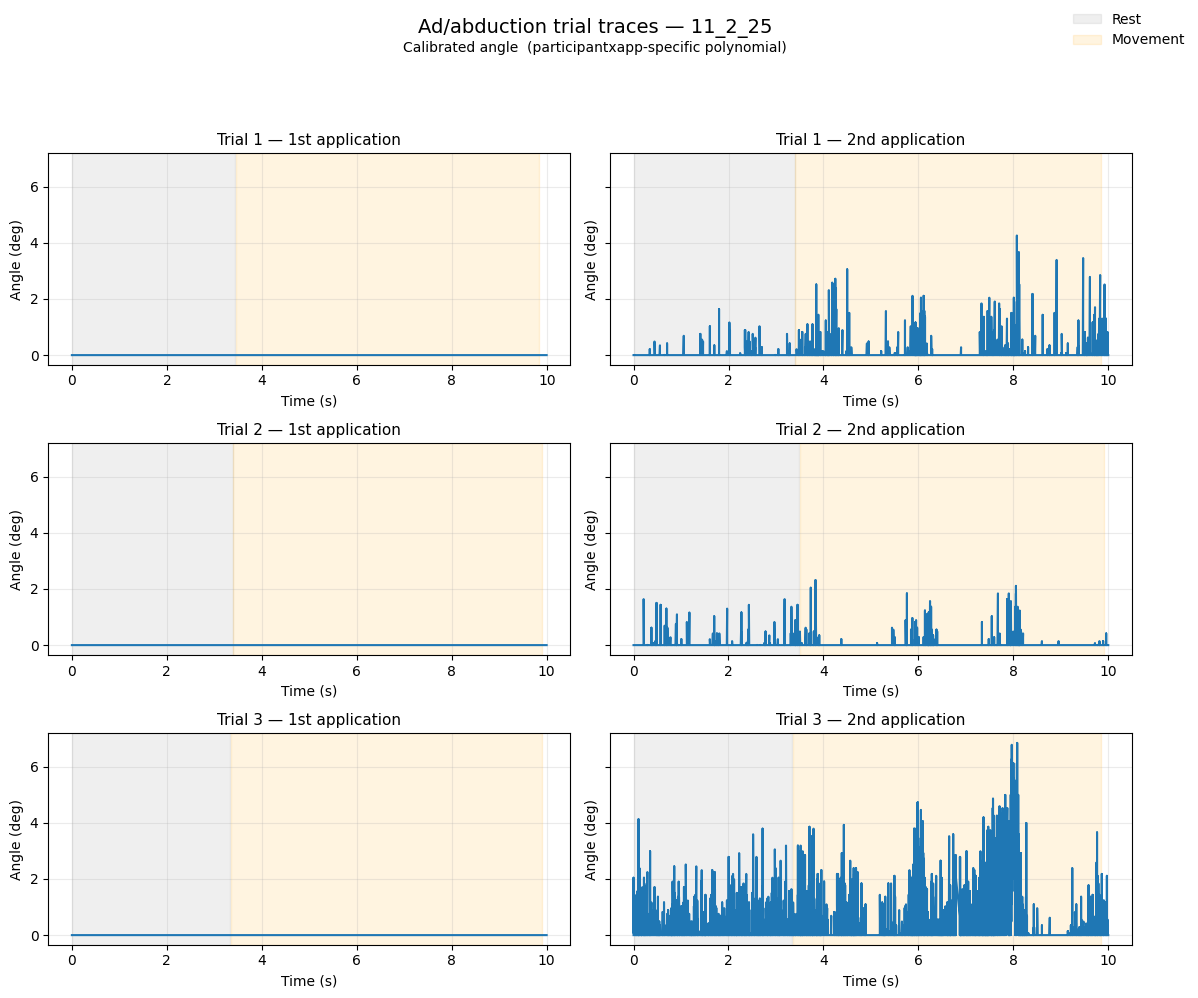

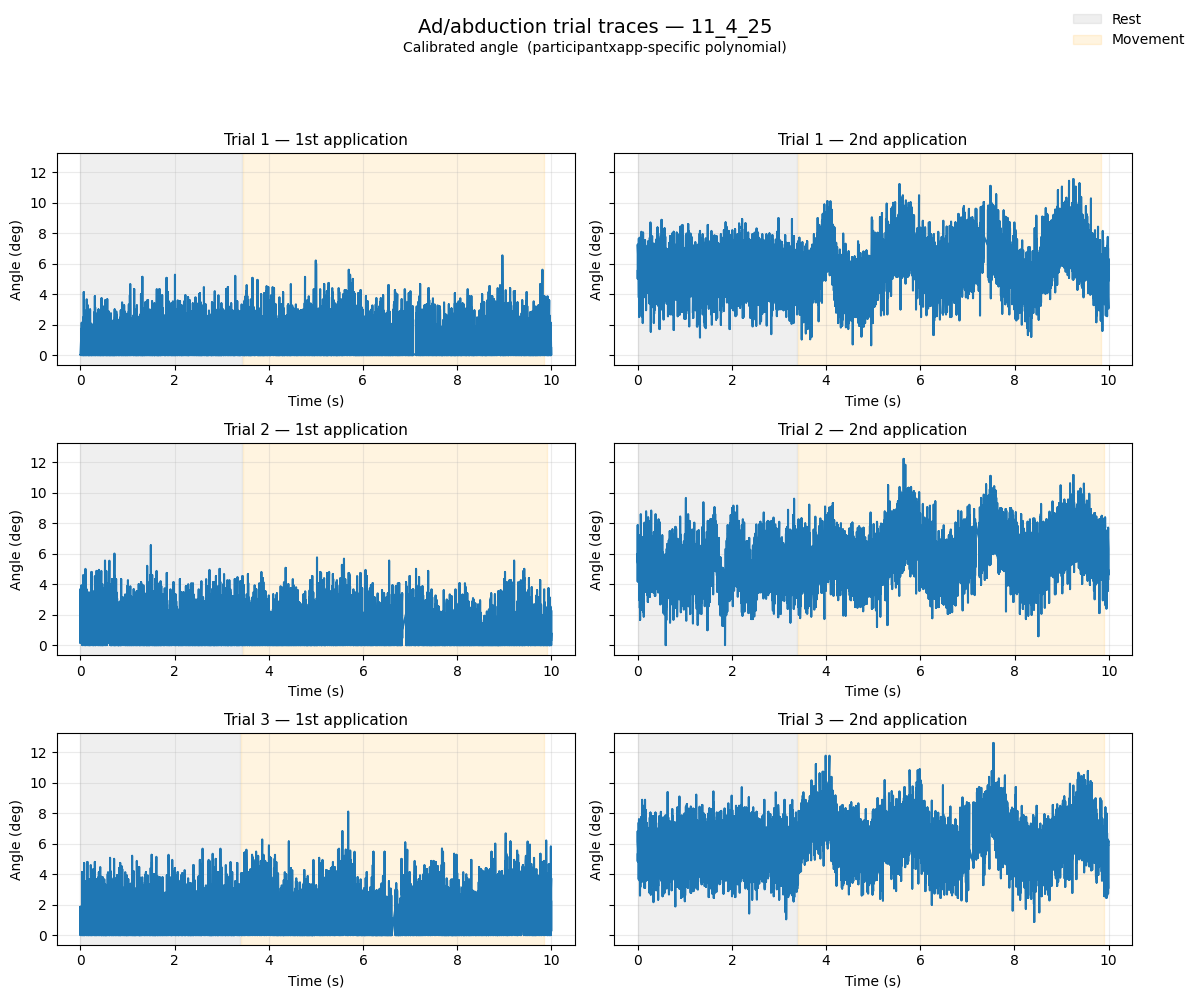

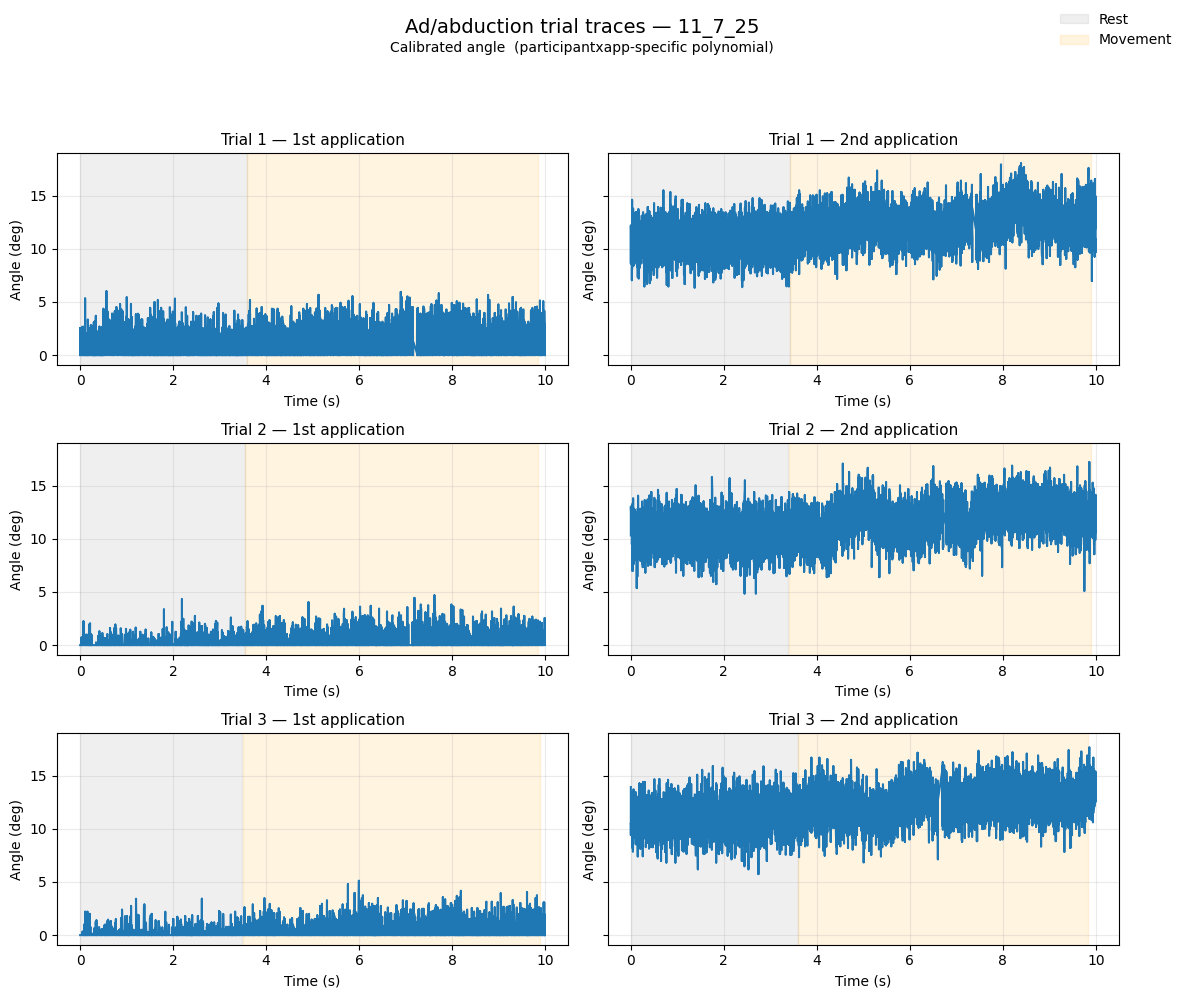

In [45]:
for participant, spec in PARTICIPANTS.items():
    res = results_clamped[participant]
    plot_adab_trial_grid(
        res,
        windows_first=spec["windows_first"],
        windows_second=spec["windows_second"],
        y_col="theta_cam_cal",
        y_label="Angle (deg)",
        fig_title=f"Ad/abduction trial traces — {participant}",
        fig_subtitle="Calibrated angle  (participantxapp-specific polynomial)",
    )
    plt.show()

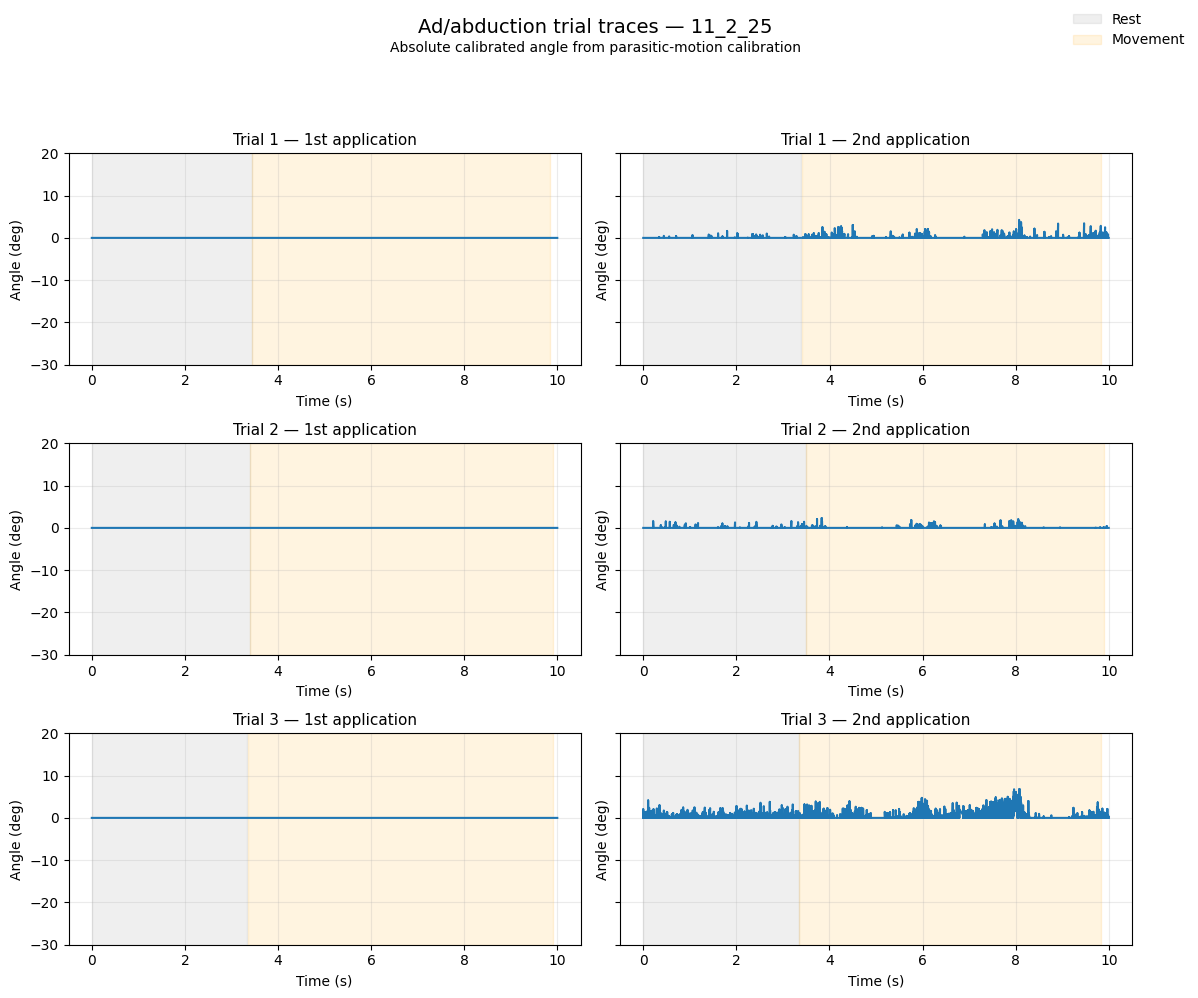

In [46]:
res_11_2 = load_adab_participant(
    participant="11_2_25",
    root_dir=PARTICIPANTS["11_2_25"]["root_dir"],
    clamp_theta=True,  # start unclamped so we can see offsets
)

plot_adab_trial_grid(
    res_11_2,
    windows_first=PARTICIPANTS["11_2_25"]["windows_first"],
    windows_second=PARTICIPANTS["11_2_25"]["windows_second"],
    y_col="theta_cam_cal",
    y_label="Angle (deg)",
    fig_title="Ad/abduction trial traces — 11_2_25",
    fig_subtitle="Absolute calibrated angle from parasitic-motion calibration",
    ylim=(-30,20),
);

# same plots for MCP to compare jump from app1 -> app2 just use first speed -- checking for 10dg offset

In [47]:
summary_11_2 = summarize_participant_adab(
    res_11_2,
    windows_first=PARTICIPANTS["11_2_25"]["windows_first"],
    windows_second=PARTICIPANTS["11_2_25"]["windows_second"],
)

summary_11_2

,participant,application,trial,rest_start_s,rest_end_s,move_start_s,move_end_s,rest_angle_n,rest_angle_mean,rest_angle_std,...,rest_adc_min,rest_adc_max,rest_adc_ptp,move_adc_n,move_adc_mean,move_adc_std,move_adc_min,move_adc_max,move_adc_ptp,move_mean_minus_rest_mean_adc
0,11_2_25,app1,1,0.0,3.44,3.45,9.84,2395,0.000000,0.000000,...,9123145.0,9170931.0,47786.0,4445,9.149614e+06,8131.899918,9126900.0,9174686.0,47786.0,2345.565626
1,11_2_25,app1,2,0.0,3.39,3.40,9.90,2360,0.000000,0.000000,...,9125535.0,9173662.0,48127.0,4535,9.149296e+06,8326.020388,9122292.0,9175368.0,53076.0,1971.218694
2,11_2_25,app1,3,0.0,3.34,3.35,9.90,2320,0.000000,0.000000,...,9121439.0,9169907.0,48468.0,4560,9.147249e+06,8519.360351,9123145.0,9174003.0,50858.0,1787.336993
3,11_2_25,app2,1,0.0,3.39,3.40,9.84,2365,0.007846,0.077468,...,9145161.0,9173321.0,28160.0,4485,9.156933e+06,4593.430402,9138505.0,9175027.0,36522.0,-1521.558873
4,11_2_25,app2,2,0.0,3.49,3.50,9.90,2430,0.012874,0.112750,...,9145161.0,9170931.0,25770.0,4440,9.159185e+06,4747.532273,9143454.0,9175368.0,31914.0,1796.154719
5,11_2_25,app2,3,0.0,3.34,3.35,9.84,2325,0.128679,0.413957,...,9138846.0,9167518.0,28672.0,4515,9.153307e+06,5782.893168,9131849.0,9171443.0,39594.0,-235.531199


In [48]:
summary_clean = summary_11_2[
    [
        "participant",
        "application",
        "trial",
        "movement_mean_angle_deg",
        "movement_peak_angle_deg",
        "movement_ptp_angle_deg",
        "move_mean_minus_rest_mean_angle",
        "rest_adc_mean",
        "move_adc_mean",
        "move_mean_minus_rest_mean_adc",
    ]
].copy()

summary_clean = summary_clean.rename(columns={
    "move_mean_minus_rest_mean_angle": "move_mean_minus_rest_mean_angle_deg"
})

summary_clean

,participant,application,trial,movement_mean_angle_deg,movement_peak_angle_deg,movement_ptp_angle_deg,move_mean_minus_rest_mean_angle_deg,rest_adc_mean,move_adc_mean,move_mean_minus_rest_mean_adc
0,11_2_25,app1,1,0.000000,0.000000,0.000000,0.000000,9.147269e+06,9.149614e+06,2345.565626
1,11_2_25,app1,2,0.000000,0.000000,0.000000,0.000000,9.147325e+06,9.149296e+06,1971.218694
2,11_2_25,app1,3,0.000000,0.000000,0.000000,0.000000,9.145462e+06,9.147249e+06,1787.336993
3,11_2_25,app2,1,0.039994,4.256263,4.256263,0.032149,9.158454e+06,9.156933e+06,-1521.558873
4,11_2_25,app2,2,0.014387,2.312202,2.312202,0.001513,9.157389e+06,9.159185e+06,1796.154719
5,11_2_25,app2,3,0.348164,6.838443,6.838443,0.219485,9.153543e+06,9.153307e+06,-235.531199


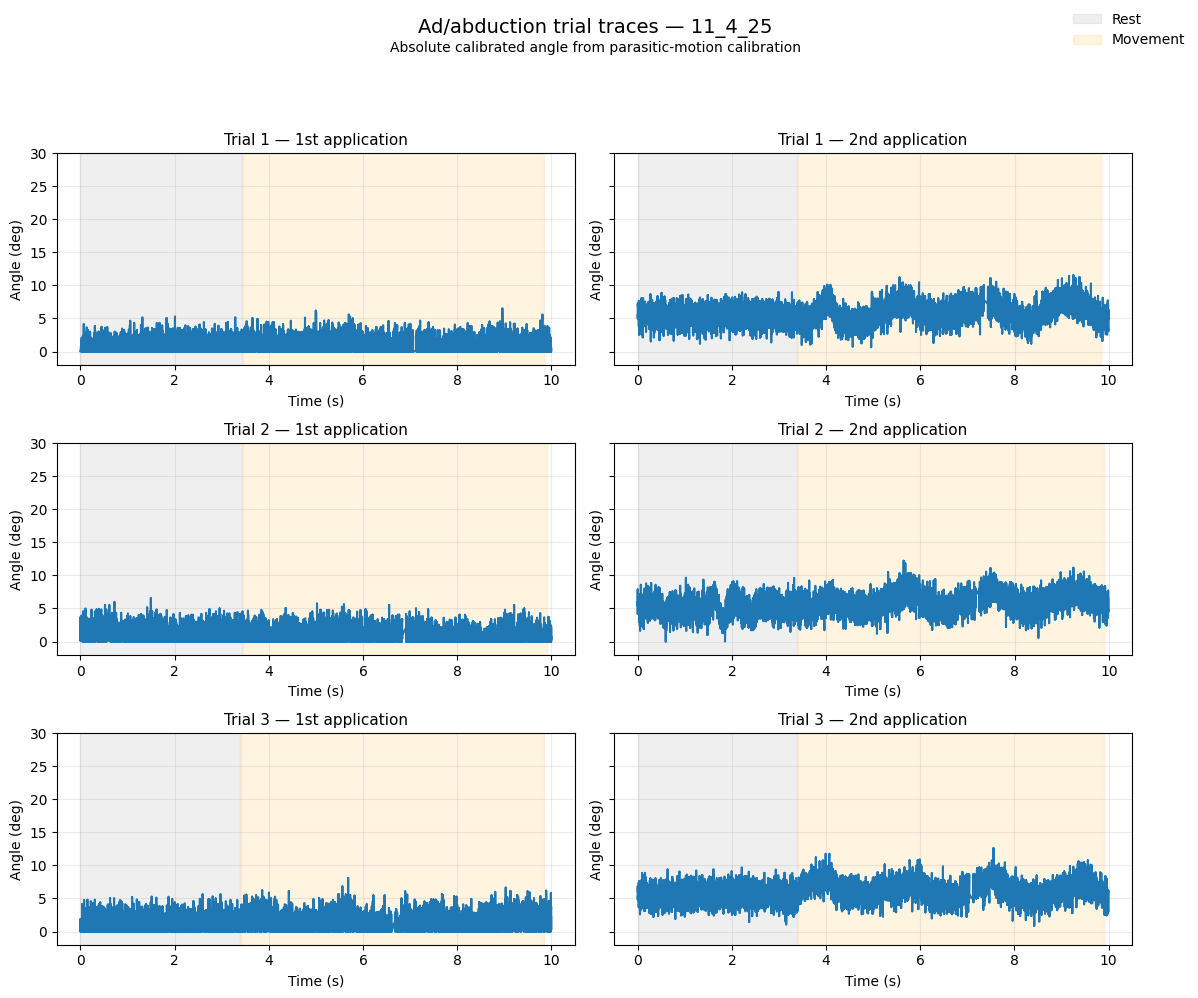

In [49]:
res_11_4 = load_adab_participant(
    participant="11_4_25",
    root_dir=PARTICIPANTS["11_4_25"]["root_dir"],
    clamp_theta=True,
)

plot_adab_trial_grid(
    res_11_4,
    windows_first=PARTICIPANTS["11_4_25"]["windows_first"],
    windows_second=PARTICIPANTS["11_4_25"]["windows_second"],
    y_col="theta_cam_cal",
    y_label="Angle (deg)",
    fig_title="Ad/abduction trial traces — 11_4_25",
    fig_subtitle="Absolute calibrated angle from parasitic-motion calibration",
    ylim=(-2, 30),
);

In [50]:
summary_11_4 = summarize_participant_adab(
    res_11_4,
    windows_first=PARTICIPANTS["11_4_25"]["windows_first"],
    windows_second=PARTICIPANTS["11_4_25"]["windows_second"],
)

summary_11_4

,participant,application,trial,rest_start_s,rest_end_s,move_start_s,move_end_s,rest_angle_n,rest_angle_mean,rest_angle_std,...,rest_adc_min,rest_adc_max,rest_adc_ptp,move_adc_n,move_adc_mean,move_adc_std,move_adc_min,move_adc_max,move_adc_ptp,move_mean_minus_rest_mean_adc
0,11_4_25,app1,1,0.0,3.44,3.45,9.84,2400,0.887147,1.015758,...,9145673.0,9170419.0,24746.0,4450,9.157508e+06,3972.487294,9142430.0,9171955.0,29525.0,-344.080253
1,11_4_25,app1,2,0.0,3.44,3.45,9.90,2395,1.211749,1.195132,...,9142430.0,9171443.0,29013.0,4485,9.157547e+06,3908.985230,9144478.0,9171443.0,26965.0,874.238167
2,11_4_25,app1,3,0.0,3.39,3.40,9.84,2360,1.319344,1.223481,...,9144649.0,9169054.0,24405.0,4480,9.155869e+06,4023.946846,9138505.0,9171955.0,33450.0,-407.425647
3,11_4_25,app2,1,0.0,3.39,3.40,9.84,2365,5.353999,1.282036,...,9148574.0,9172467.0,23893.0,4475,9.157582e+06,5113.468349,9140724.0,9174003.0,33279.0,-2094.318753
4,11_4_25,app2,2,0.0,3.39,3.40,9.90,2360,5.109337,1.422776,...,9146526.0,9180488.0,33962.0,4515,9.157363e+06,4714.386249,9138676.0,9174174.0,35498.0,-3060.671308
5,11_4_25,app2,3,0.0,3.39,3.40,9.90,2365,5.567191,1.303002,...,9146356.0,9172809.0,26453.0,4520,9.156721e+06,4652.271744,9137481.0,9173321.0,35840.0,-2306.128932


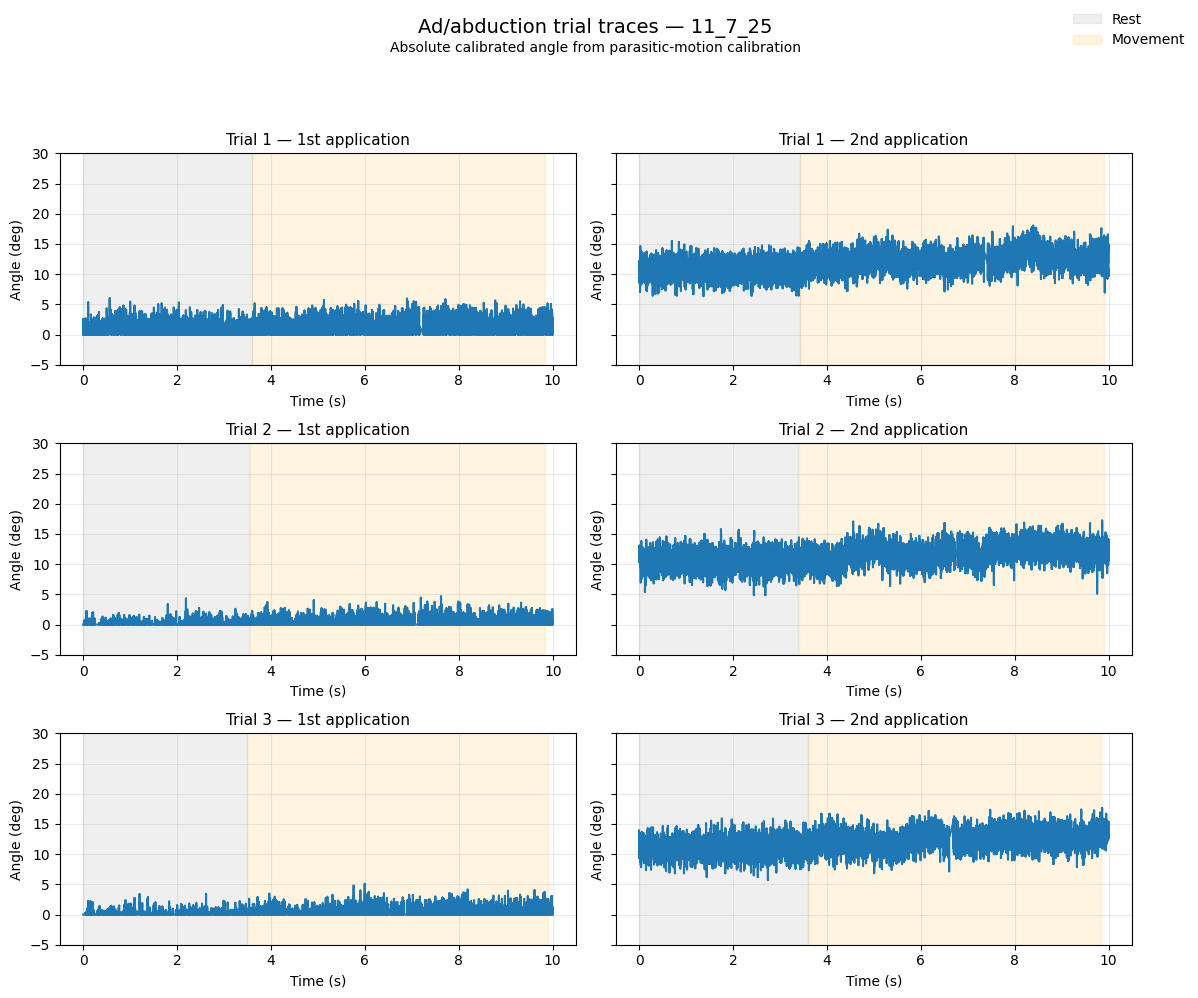

In [51]:
res_11_7 = load_adab_participant(
    participant="11_7_25",
    root_dir=PARTICIPANTS["11_7_25"]["root_dir"],
    clamp_theta=True,
)

plot_adab_trial_grid(
    res_11_7,
    windows_first=PARTICIPANTS["11_7_25"]["windows_first"],
    windows_second=PARTICIPANTS["11_7_25"]["windows_second"],
    y_col="theta_cam_cal",
    y_label="Angle (deg)",
    fig_title="Ad/abduction trial traces — 11_7_25",
    fig_subtitle="Absolute calibrated angle from parasitic-motion calibration",
    ylim=(-5, 30),
);

# look at calibration curve of each app 1v2 to see if that messes w offset
# combine across participants, trials, 


In [52]:
summary_11_7 = summarize_participant_adab(
    res_11_7,
    windows_first=PARTICIPANTS["11_7_25"]["windows_first"],
    windows_second=PARTICIPANTS["11_7_25"]["windows_second"],
)

summary_11_7

,participant,application,trial,rest_start_s,rest_end_s,move_start_s,move_end_s,rest_angle_n,rest_angle_mean,rest_angle_std,...,rest_adc_min,rest_adc_max,rest_adc_ptp,move_adc_n,move_adc_mean,move_adc_std,move_adc_min,move_adc_max,move_adc_ptp,move_mean_minus_rest_mean_adc
0,11_7_25,app1,1,0.0,3.59,3.60,9.84,2500,0.938239,1.049262,...,9105055.0,9134238.0,29183.0,4335,9.117083e+06,3707.707803,9105226.0,9129119.0,23893.0,-1538.108569
1,11_7_25,app1,2,0.0,3.54,3.55,9.84,2465,0.109935,0.355994,...,9109322.0,9135945.0,26623.0,4370,9.121529e+06,3729.604200,9108298.0,9134409.0,26111.0,-2650.812946
2,11_7_25,app1,3,0.0,3.49,3.50,9.90,2430,0.088478,0.323606,...,9111540.0,9135262.0,23722.0,4460,9.121617e+06,3854.747509,9107274.0,9134238.0,26964.0,-2752.365843
3,11_7_25,app2,1,0.0,3.42,3.43,9.90,2385,10.819691,1.491233,...,9059658.0,9082015.0,22357.0,4495,9.067395e+06,4043.783606,9053002.0,9080138.0,27136.0,-3831.936037
4,11_7_25,app2,2,0.0,3.39,3.40,9.90,2360,10.528366,1.512658,...,9058805.0,9085429.0,26624.0,4530,9.068663e+06,4104.118002,9055221.0,9084917.0,29696.0,-3272.747695
5,11_7_25,app2,3,0.0,3.59,3.60,9.84,2500,11.118835,1.493311,...,9058634.0,9083381.0,24747.0,4330,9.067403e+06,3862.093999,9054709.0,9080821.0,26112.0,-3094.114691


In [53]:
# all participants
results = {}
summary_tables = []
calib_tables = []

for participant, spec in PARTICIPANTS.items():
    result = load_adab_participant(
        participant=participant,
        root_dir=spec["root_dir"],
        clamp_theta=False,
    )
    results[participant] = result

    summary_df = summarize_participant_adab(
        result,
        windows_first=spec["windows_first"],
        windows_second=spec["windows_second"],
    )
    summary_tables.append(summary_df)

    calib_df = collect_calibration_points(result)
    calib_tables.append(calib_df)

In [54]:
all_summary = pd.concat(summary_tables, ignore_index=True)
all_calib = pd.concat(calib_tables, ignore_index=True)

all_summary

,participant,application,trial,rest_start_s,rest_end_s,move_start_s,move_end_s,rest_angle_n,rest_angle_mean,rest_angle_std,...,rest_adc_min,rest_adc_max,rest_adc_ptp,move_adc_n,move_adc_mean,move_adc_std,move_adc_min,move_adc_max,move_adc_ptp,move_mean_minus_rest_mean_adc
0,11_2_25,app1,1,0.0,3.44,3.45,9.84,2395,-20.061278,4.537679,...,9123145.0,9170931.0,47786.0,4445,9.149614e+06,8131.899918,9126900.0,9174686.0,47786.0,2345.565626
1,11_2_25,app1,2,0.0,3.39,3.40,9.90,2360,-20.100195,4.773047,...,9125535.0,9173662.0,48127.0,4535,9.149296e+06,8326.020388,9122292.0,9175368.0,53076.0,1971.218694
2,11_2_25,app1,3,0.0,3.34,3.35,9.90,2320,-19.019043,4.869226,...,9121439.0,9169907.0,48468.0,4560,9.147249e+06,8519.360351,9123145.0,9174003.0,50858.0,1787.336993
3,11_2_25,app2,1,0.0,3.39,3.40,9.84,2365,-3.712866,1.670344,...,9145161.0,9173321.0,28160.0,4485,9.156933e+06,4593.430402,9138505.0,9175027.0,36522.0,-1521.558873
4,11_2_25,app2,2,0.0,3.49,3.50,9.90,2430,-3.279098,1.659454,...,9145161.0,9170931.0,25770.0,4440,9.159185e+06,4747.532273,9143454.0,9175368.0,31914.0,1796.154719
5,11_2_25,app2,3,0.0,3.34,3.35,9.84,2325,-1.721735,1.675096,...,9138846.0,9167518.0,28672.0,4515,9.153307e+06,5782.893168,9131849.0,9171443.0,39594.0,-235.531199
6,11_4_25,app1,1,0.0,3.44,3.45,9.84,2400,0.514547,1.477023,...,9145673.0,9170419.0,24746.0,4450,9.157508e+06,3972.487294,9142430.0,9171955.0,29525.0,-344.080253
7,11_4_25,app1,2,0.0,3.44,3.45,9.90,2395,0.973580,1.519977,...,9142430.0,9171443.0,29013.0,4485,9.157547e+06,3908.985230,9144478.0,9171443.0,26965.0,874.238167
8,11_4_25,app1,3,0.0,3.39,3.40,9.84,2360,1.127807,1.492781,...,9144649.0,9169054.0,24405.0,4480,9.155869e+06,4023.946846,9138505.0,9171955.0,33450.0,-407.425647
9,11_4_25,app2,1,0.0,3.39,3.40,9.84,2365,5.353999,1.282036,...,9148574.0,9172467.0,23893.0,4475,9.157582e+06,5113.468349,9140724.0,9174003.0,33279.0,-2094.318753


In [55]:
summary_clean = all_summary[
    [
        "participant",
        "application",
        "trial",
        "movement_mean_angle_deg",
        "movement_peak_angle_deg",
        "movement_ptp_angle_deg",
        "move_mean_minus_rest_mean_angle",
        "rest_adc_mean",
        "move_adc_mean",
        "move_mean_minus_rest_mean_adc",
    ]
].copy()

summary_clean = summary_clean.rename(columns={
    "move_mean_minus_rest_mean_angle": "move_mean_minus_rest_mean_angle_deg"
})

summary_clean

,participant,application,trial,movement_mean_angle_deg,movement_peak_angle_deg,movement_ptp_angle_deg,move_mean_minus_rest_mean_angle_deg,rest_adc_mean,move_adc_mean,move_mean_minus_rest_mean_adc
0,11_2_25,app1,1,-21.441784,-8.515046,28.231370,-1.380506,9.147269e+06,9.149614e+06,2345.565626
1,11_2_25,app1,2,-21.257755,-6.028952,31.152728,-1.157559,9.147325e+06,9.149296e+06,1971.218694
2,11_2_25,app1,3,-20.061832,-6.486025,29.825401,-1.042790,9.145462e+06,9.147249e+06,1787.336993
3,11_2_25,app2,1,-3.095621,4.256263,14.830551,0.617245,9.158454e+06,9.156933e+06,-1521.558873
4,11_2_25,app2,2,-4.013233,2.312202,13.030237,-0.734135,9.157389e+06,9.159185e+06,1796.154719
5,11_2_25,app2,3,-1.633552,6.838443,15.907819,0.088183,9.153543e+06,9.153307e+06,-235.531199
6,11_4_25,app1,1,0.648613,6.551708,11.488445,0.134066,9.157852e+06,9.157508e+06,-344.080253
7,11_4_25,app1,2,0.633388,5.744800,10.484957,-0.340193,9.156673e+06,9.157547e+06,874.238167
8,11_4_25,app1,3,1.286770,8.102322,13.039060,0.158963,9.156277e+06,9.155869e+06,-407.425647
9,11_4_25,app2,1,6.040886,11.560091,10.919028,0.686887,9.159677e+06,9.157582e+06,-2094.318753


In [56]:
summary_grouped = (
    summary_clean
    .groupby(["participant", "application"], as_index=False)
    .agg(
        mean_movement_angle_deg=("movement_mean_angle_deg", "mean"),
        mean_peak_angle_deg=("movement_peak_angle_deg", "mean"),
        mean_ptp_angle_deg=("movement_ptp_angle_deg", "mean"),
        mean_delta_angle_deg=("move_mean_minus_rest_mean_angle_deg", "mean"),
        sd_delta_angle_deg=("move_mean_minus_rest_mean_angle_deg", "std"),
        mean_adc_shift=("move_mean_minus_rest_mean_adc", "mean"),
        sd_adc_shift=("move_mean_minus_rest_mean_adc", "std"),
    )
)

summary_grouped

,participant,application,mean_movement_angle_deg,mean_peak_angle_deg,mean_ptp_angle_deg,mean_delta_angle_deg,sd_delta_angle_deg,mean_adc_shift,sd_adc_shift
0,11_2_25,app1,-20.920457,-7.010008,29.736500,-1.193618,0.171722,2034.707104,284.478268
1,11_2_25,app2,-2.914135,4.468969,14.589535,-0.009569,0.680973,13.021549,1672.764096
2,11_4_25,app1,0.856257,6.799610,11.670821,-0.015721,0.281276,40.910756,722.377388
3,11_4_25,app2,6.159198,12.135680,11.438463,0.815961,0.166958,-2487.039664,507.942747
4,11_7_25,app1,0.037159,5.261122,10.156543,0.914785,0.264920,-2313.762453,673.652327
5,11_7_25,app2,12.207342,17.566506,11.227642,1.385045,0.156401,-3399.599474,384.920271
